<a href="https://colab.research.google.com/github/smithve-laf/smith-repository-notebook/blob/main/coding_homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Tori Smith
#####*Intro to Neural Data Analysis*
#####**04/03/2026**

In [1]:
#step 2
#importing packages
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#step 3
#importing data

url1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial1.csv'
url2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial2.csv'
url3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial1.csv'
url4 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial2.csv'

spikes_left_trial1 = np.loadtxt(url1, delimiter = ',')
spikes_left_trial2 = np.loadtxt(url2, delimiter = ',')
spikes_right_trial1 = np.loadtxt(url3, delimiter = ',')
spikes_right_trial2 = np.loadtxt(url4, delimiter = ',')

In [3]:
#step 4
#checking length of each array
print(len(spikes_left_trial1))
print(len(spikes_left_trial2))
print(len(spikes_right_trial1))
print(len(spikes_right_trial2))

65
53
45
69


In [13]:
#step 6
#find fire rate of this neuron during each trial (first and second left turn, first and second right turn)
#30 second waiting peirod, length of recording for spikes. does the firing rate during this waiting predict direction the rat turns in next trial?

firing_rate_left1 = 65/30
print(firing_rate_left1)
firing_rate_left2 = 53/30
print(firing_rate_left2)
firing_rate_right1 = 45/30
print(firing_rate_left1)
firing_rate_left2 = 69/30
print(firing_rate_left2)

2.1666666666666665
1.7666666666666666
2.1666666666666665
2.3


#####7. Do you think this neuron fires more before left turn trials, or right turn trials?
#####Based on these firing rates, this neuron fires more during right turn trials on average.

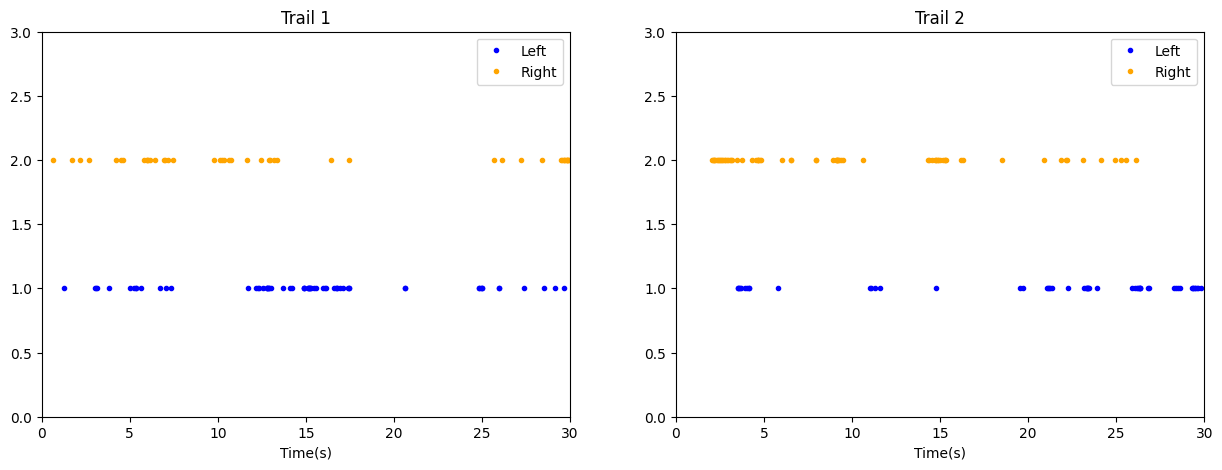

In [36]:
#step 8
#make two subplots
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].plot(spikes_left_trial1, np.ones_like(spikes_left_trial1), '.', color = 'blue')
ax[0].plot(spikes_right_trial1, 2 * np.ones_like(spikes_right_trial1), '.', color = 'orange')
ax[0].set_xlim([0,30]) #display times over 30 seconds
ax[0].set_ylim([0,3])
ax[0].set_xlabel('Time(s)')
ax[0].set_title('Trail 1')
ax[0].legend({'Left', 'Right'})

ax[1].plot(spikes_left_trial2, np.ones_like(spikes_left_trial2), '.', color = 'blue')
ax[1].plot(spikes_right_trial2, 2 * np.ones_like(spikes_right_trial2), '.', color = 'orange')
ax[1].set_xlim([0,30]) #display times over 30 seconds
ax[1].set_ylim([0,3])
ax[1].set_xlabel('Time(s)')
ax[1].set_title('Trail 2')
ax[1].legend({'Left', 'Right'})


#####9. Does this neuron seem more "bursty", or more regular-firing, during left or right turn trials.
#####In both I think they are bursty because of the gaps in firing at certain times. In trial 1, left turn neurons fire in the middle, but in trial 2 they are more bursty at the end. For right turn neurons, in trial one, they kind of fire between 5-15 seconds, but in trial 2 they are more bursty at the beginning.

In [23]:
#step 10
#calculate inter-spike interval (ISI) arrays for each.
isi_left1 = np.diff(spikes_left_trial1)
isi_left2 = np.diff(spikes_left_trial2)
isi_right1 = np.diff(spikes_right_trial1)
isi_right2 = np.diff(spikes_right_trial2)

Text(0.5, 1.0, 'Right - Trial 2')

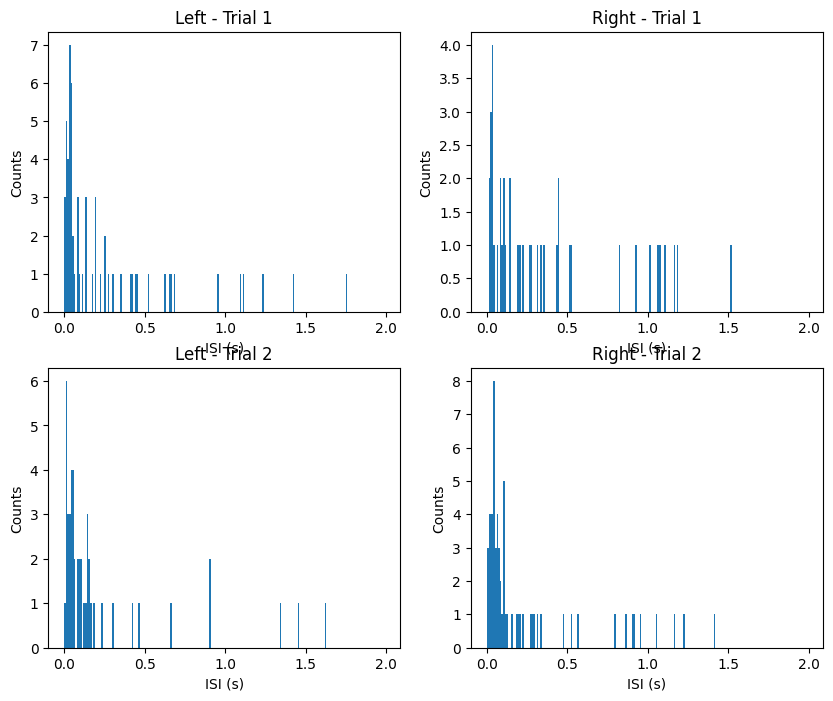

In [26]:
#step 11
#4 histograms
bins = np.arange(0, 2, 0.01)

fig, ax = plt.subplots(2,2, figsize = (10,8))

ax[0,0].hist(isi_left1, bins)
ax[0,0].set_xlabel('ISI (s)')
ax[0,0].set_ylabel('Counts')
ax[0,0].set_title('Left - Trial 1')

ax[0,1].hist(isi_right1, bins)
ax[0,1].set_xlabel('ISI (s)')
ax[0,1].set_ylabel('Counts')
ax[0,1].set_title('Right - Trial 1')

ax[1,0].hist(isi_left2, bins)
ax[1,0].set_xlabel('ISI (s)')
ax[1,0].set_ylabel('Counts')
ax[1,0].set_title('Left - Trial 2')

ax[1,1].hist(isi_right2, bins)
ax[1,1].set_xlabel('ISI (s)')
ax[1,1].set_ylabel('Counts')
ax[1,1].set_title('Right - Trial 2')

#####12. Does this neuron tend to fire in 'bursts'? Does it have higher burstiness during left or right turn trials?
#####In all four trials, there is a large concentration of short ISIs starting at 0 seconds. For left turns, there is strong clustering at 0 but they seem to slightly spread. In right turn trials, there is sharp peaks very close to zero, stronger bursts here. Right turns on trial 2 seem to be the most bursty.

Text(0.5, 1.0, 'Trial 2')

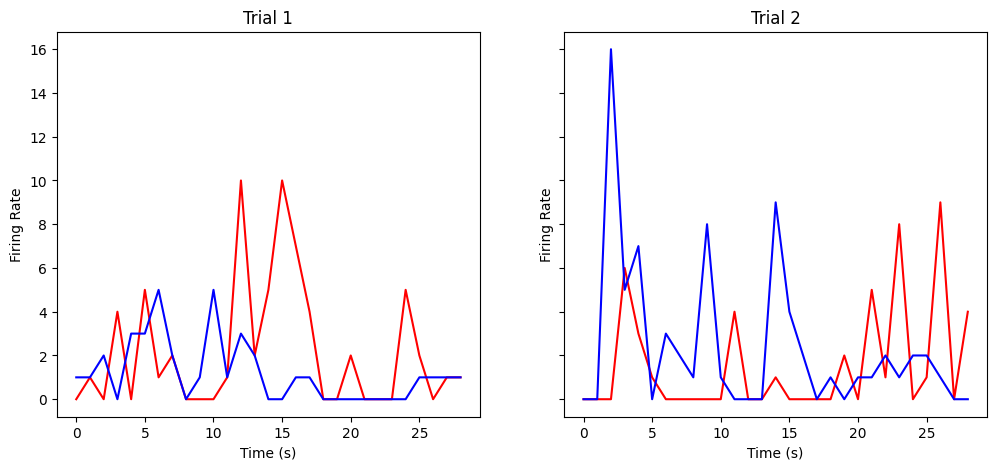

In [35]:
#step 13
#firing rate (spike counts per bin) and subplots
time_bins = np.arange(0, 30, 1)
fr_left1, _ = np.histogram(spikes_left_trial1, time_bins)
fr_right1, _ = np.histogram(spikes_right_trial1, time_bins)
fr_left2, _ = np.histogram(spikes_left_trial2, time_bins)
fr_right2, _ = np.histogram(spikes_right_trial2, time_bins)

#subplots
fig, ax = plt.subplots(1,2, figsize =(12,5), sharey=True) #sharey=True sets graphs to same range

ax[0].plot(time_bins[:-1], fr_left1, color = 'red')
ax[0].plot(time_bins[:-1], fr_right1, color = 'blue')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Firing Rate')
ax[0].set_title('Trial 1')

ax[1].plot(time_bins[:-1], fr_left2, color = 'red')
ax[1].plot(time_bins[:-1], fr_right2, color = 'blue')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Firing Rate')
ax[1].set_title('Trial 2')

#####14. Does the firing rate between left and right turn trials differ at specific timepoints during the 30s waiting period? Is the pattern different for trial 1 and trial 2?
#####When turning left, firing rate spikes between 10-20 seconds most intensly in the first trial and in the second trial, it spikes alittle in the first 5 seconds and mostly in the last 10 seconds. When turning right, the first trial doesn't show very intense firing rate spikes, little between 4-14 seconds. But in trial two, firing rate has a huge spike in the first 5 seconds, and still continues throughout until about 18 seconds.
#####For trial 1, neurons for left turns are most active during the middle of the waiting period. For right turns, firing is low, meaning these neurons are relatively quiet during this trial.
#####For trial 2, left turn neurons spike later in the trial. Right turn neurons fire earlier and more intensely than in trial 1. This suggests turn-specific activity